<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/ML_Projects/Customer%20Segmentation/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%%markdown
---
Loading and Cleaning the Dataset

---
Loading and Cleaning the Dataset


In [4]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel('Online Retail.xlsx')
df.head()

Saving Online Retail.xlsx to Online Retail (4).xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.dropna(inplace=True)
df.reset_index(inplace = True,drop = True)


In [7]:
df.shape

(406829, 8)

In [8]:
new_df = df.copy()

In [9]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406829 entries, 0 to 406828
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.8+ MB


In [10]:
%%markdown
---
Data Cleaning and Preprocessing

---
Data Cleaning and Preprocessing


In [11]:
new_df.drop(axis=1,columns='InvoiceDate',inplace=True)
new_df = new_df.dropna(subset=['CustomerID'])
new_df = new_df[~new_df['InvoiceNo'].astype(str).str.startswith('C')]
new_df= new_df[new_df['Quantity'] > 0]
new_df = new_df[new_df["UnitPrice"] > 0]
new_df['TotalAmount'] = new_df['Quantity'] * new_df['UnitPrice']

In [12]:
new_df.shape

(397884, 8)

In [13]:
new_df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1462


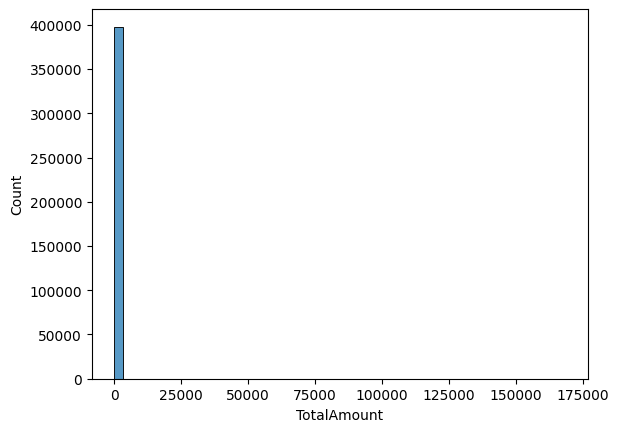

In [14]:
sns.histplot(new_df['TotalAmount'],bins = 50)
plt.show()